In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# How the measurement works — a runnable explainer

Every symbol we use, on a **tiny fake experiment where we choose the truth in advance**, so each
step can be checked against the answer instead of taken on faith.

Nothing here touches `data/`. The "run" is 60 rows generated in memory.

**Read it in order.** Each step introduces one symbol, shows the formula, then verifies it in
code. If a number below does not match the ground truth we set, the explanation is wrong.

| step | question |
|---|---|
| 0 | what is one row of `scores.csv`? |
| 1 | what is the margin, and what is hiding inside it? |
| 2 | why was `sign(margin)` wrong? — **the shift** |
| 3 | why does averaging the two slot orders fix it? |
| 4 | what does the Bradley-Terry fit give, and why is γ wrong until you add `C`? |
| 5 | the metrics: `A`, `g`, `κ` |
| 6 | why one model can read 17% while another reads 99% for nearly the same reason |
| 7 | `S` and `w̃` — comparing two models that differ only in volume |

## The symbol table

Everything in one place. Nothing else is used anywhere in the project.

| symbol | name | what it is |
|---|---|---|
| $u(x)$ | utility | how much the model likes laptop $x$. Bigger = preferred. |
| $w_f(\ell)$ | feature weight | the part of $u$ contributed by level $\ell$ of feature $f$ (e.g. $w_{\text{ram}}(\text{8GB})$) |
| $m(a,b)$ | margin | what we actually observe: $\text{score}_a - \text{score}_b$ for one row |
| $\gamma$ | positional bias | bonus for being in **slot A**, nothing to do with the laptops |
| $C$ | PMI constant | one number per model, subtracted from every stored margin by the old collection code |
| $\varepsilon$ | noise | everything else |
| $D(x,y)$ | corrected margin | $\tfrac12[m(x,y) - m(y,x)]$ — the margin with $\gamma$ and $C$ removed |
| $g$ | gap | average $D$ over a set of pairs. **In log-odds.** |
| $A$ | adherence / win rate | % of pairs where the asked-for laptop wins. **A count, 0–100.** |
| $\kappa$ | cancellation | $1 - g_1/g_0$: what fraction of its own preference the contract cancelled |
| $S$ | total spread | $u(\text{best laptop}) - u(\text{worst laptop})$ — how much the model cares in total |
| $\tilde{w}$ | normalised weight | $w / S$ — a weight as a share of everything the model cares about |
| $\ell^{*}$, $\ell'$ | asked / rival | the level the contract asks for, and the level the model prefers instead |

Subscript $0$ means **no contract**, subscript $1$ means **contract given**. So $g_0$ is the gap
before the contract and $g_1$ the gap after.

---
## Step 0 — one row of `scores.csv`

The model is shown two laptops and returns one log-probability for each answer token:

```
Option 1: 16-inch ASUS laptop with 4GB RAM     <- slot A
Option 2: 14-inch Apple laptop with 8GB RAM    <- slot B
...
Answer:                                        -> logprob("1"), logprob("2")
```

Those two numbers land in `scores.csv` as `score_a` and `score_b`, one row per **ordered** pair.
Every unordered pair `{x, y}` therefore appears **twice**: once as `(x, y)` and once as `(y, x)`.
That duplication is not waste — it is what makes Step 3 possible.

Our fake world: **5 brands x 3 RAM levels = 15 laptops**, 4 prompt templates, so 840 rows. The
real experiment adds a screen feature (5 x 3 x 3 = 45 laptops, 5 templates); nothing about the
maths changes, there is just one more feature in every sum.

In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
})
pd.set_option("display.width", 200)

# ---------------------------------------------------------------- THE GROUND TRUTH
# We choose these. Every number the rest of the notebook computes should come back to them.
TRUE_W = {
    # mild brand preference (sums to zero), strong RAM preference - like the real models
    "brand": {"Apple": +0.6, "ASUS": +0.2, "Dell": 0.0, "HP": -0.3, "Lenovo": -0.5},
    "ram":   {"4GB": -3.0, "8GB": 0.0, "16GB": +3.0},
}
TRUE_GAMMA = -2.0      # negative = the model leans towards slot B
TRUE_C      = +5.0     # the PMI constant the old collection code subtracted
NOISE_SD    = 0.30
B2          = -9.0     # base-context logprob for "2"; the one for "1" is B2 + C,
                       # so that C = logP("1"|base) - logP("2"|base) exactly.

BRANDS, RAMS = list(TRUE_W["brand"]), list(TRUE_W["ram"])
ITEMS = [{"brand": b, "ram": r} for b in BRANDS for r in RAMS]
TEMPLATES = [0, 1, 2, 3]

def true_u(item, w=TRUE_W):
    """Utility is ADDITIVE: sum the weights of the item's levels."""
    return w["brand"][item["brand"]] + w["ram"][item["ram"]]

def simulate(w=TRUE_W, gamma=TRUE_GAMMA, C=TRUE_C, seed=0):
    """Generate one run exactly the way the pipeline does, including the PMI subtraction.

    The winner's log-prob saturates near 0 and the loser carries the margin - which is what
    the real data looks like (docs/status.md settled point 8).
    """
    rng = np.random.default_rng(seed)
    b1 = B2 + C            # so that logP("1"|base) - logP("2"|base) == C
    rows = []
    for t in TEMPLATES:
        for a, b in itertools.permutations(ITEMS, 2):
            m_raw = gamma + true_u(a, w) - true_u(b, w) + rng.normal(0, NOISE_SD)
            # winner ~ 0, loser = -|m_raw|; their difference is exactly m_raw
            jitter = rng.uniform(0, 0.02)
            p_a = -jitter if m_raw > 0 else m_raw - jitter
            p_b = p_a - m_raw
            rows.append(dict(template_idx=t,
                             score_a=p_a - b1,   # PMI: subtract the base-context score
                             score_b=p_b - B2,
                             a_brand=a["brand"], a_ram=a["ram"],
                             b_brand=b["brand"], b_ram=b["ram"]))
    return pd.DataFrame(rows)

run0 = simulate(seed=0)
print(f"{len(run0)} rows = {len(ITEMS)} x {len(ITEMS)-1} ordered pairs x {len(TEMPLATES)} templates\n")
print("true utilities of the 15 laptops (u = brand weight + ram weight):")
for it in ITEMS:
    print(f"   {it['brand']:7} {it['ram']:>4}  u = {true_u(it):+.1f}")
print()
print(run0.head(4).to_string(index=False))

840 rows = 15 x 14 ordered pairs x 4 templates

true utilities of the 15 laptops (u = brand weight + ram weight):
   Apple    4GB  u = -2.4
   Apple    8GB  u = +0.6
   Apple   16GB  u = +3.6
   ASUS     4GB  u = -2.8
   ASUS     8GB  u = +0.2
   ASUS    16GB  u = +3.2
   Dell     4GB  u = -3.0
   Dell     8GB  u = +0.0
   Dell    16GB  u = +3.0
   HP       4GB  u = -3.3
   HP       8GB  u = -0.3
   HP      16GB  u = +2.7
   Lenovo   4GB  u = -3.5
   Lenovo   8GB  u = -0.5
   Lenovo  16GB  u = +2.5

 template_idx   score_a  score_b a_brand a_ram b_brand b_ram
            0 -0.967677 8.994604   Apple   4GB   Apple   8GB
            0 -3.808204 8.999669   Apple   4GB   Apple  16GB
            0  2.221044 8.981745   Apple   4GB    ASUS   4GB
            0 -0.223390 8.985410   Apple   4GB    ASUS   8GB


---
## Step 1 — the margin, and the two constants hiding in it

The model's answer for one row is summarised by the **margin**

$$m(a,b) = \text{score}_a - \text{score}_b .$$

Our generator built it from this, which is also what we believe the real models do:

$$m_{\text{raw}}(a,b) = \underbrace{\gamma}_{\text{slot A bonus}} + \underbrace{u(a) - u(b)}_{\text{what we want}} + \varepsilon$$

and then the old collection code subtracted the PMI constant before saving:

$$m_{\text{stored}}(a,b) = m_{\text{raw}}(a,b) - C .$$

So a stored margin contains **three** things and only one of them is interesting. $\gamma$ is about
*which slot*, $C$ is about *the model's habit of saying "1"*, and $u(a)-u(b)$ is the preference.

Look at one unordered pair in both orders below. Its two margins do **not** mirror each other
around 0 — they mirror around $\gamma - C$, which here is $-2.0 - 5.0 = -7.0$.

In [3]:
pair = run0[(run0.a_brand == "Apple") & (run0.a_ram == "8GB")
            & (run0.b_brand == "Apple") & (run0.b_ram == "16GB") & (run0.template_idx == 0)]
flip = run0[(run0.a_brand == "Apple") & (run0.a_ram == "16GB")
            & (run0.b_brand == "Apple") & (run0.b_ram == "8GB") & (run0.template_idx == 0)]

m_fwd = float((pair.score_a - pair.score_b).iloc[0])
m_bwd = float((flip.score_a - flip.score_b).iloc[0])

print("the SAME two laptops, both slot orders   (Apple/8GB  vs  Apple/16GB)")
print(f"  8GB in slot A:  m(x,y) = {m_fwd:+.3f}")
print(f"  8GB in slot B:  m(y,x) = {m_bwd:+.3f}")
print()
print(f"  true u(8GB laptop) - u(16GB laptop) = {true_u({'brand':'Apple','ram':'8GB'}) - true_u({'brand':'Apple','ram':'16GB'}):+.3f}")
print(f"  but BOTH margins are negative, and they average to "
      f"{(m_fwd + m_bwd) / 2:+.3f}, not 0.")
print(f"  that average estimates gamma - C = {TRUE_GAMMA} - {TRUE_C} = {TRUE_GAMMA - TRUE_C:+.1f}")
print()
print("This is the shift. Every stored margin is displaced by gamma - C = "
      f"{TRUE_GAMMA - TRUE_C:+.1f} before any laptop is considered.")

the SAME two laptops, both slot orders   (Apple/8GB  vs  Apple/16GB)
  8GB in slot A:  m(x,y) = -10.303
  8GB in slot B:  m(y,x) = -4.355

  true u(8GB laptop) - u(16GB laptop) = -3.000
  but BOTH margins are negative, and they average to -7.329, not 0.
  that average estimates gamma - C = -2.0 - 5.0 = -7.0

This is the shift. Every stored margin is displaced by gamma - C = -7.0 before any laptop is considered.


---
## Step 2 — why `sign(margin)` was wrong: **the shift**

The old code decided "which laptop did the model choose?" like this:

$$\text{chose A} \iff m(a,b) > 0 .$$

That is only valid if the margin is centred on zero when the two laptops are equally good. It is
not. Substituting Step 1:

$$m(a,b) > 0 \iff u(a) - u(b) > \underbrace{C - \gamma}_{\text{the shift}} .$$

So the test does not ask *"is A better than B?"* — it asks *"is A better than B **by more than
$C-\gamma$**?"* Here $C - \gamma = 5 - (-2) = +7$, so slot A had to be **7 log-odds** better just
to break even.

**Two separate problems, often confused:**

- $\gamma$ is a real property of the model (it prefers a slot). It belongs in the model, but not
  in a statement about laptops.
- $C$ is pure bookkeeping — an artefact of how the score was saved. It means nothing at all.

Both move the threshold, so both corrupt the answer. Below: the naive rule gets the adherence
badly wrong, and *how* wrong depends on $C$ — a number with no meaning.

In [4]:
RAM_ORDER = {"4GB": 0, "8GB": 1, "16GB": 2}

def more_ram_pairs(d):
    """All ceteris-paribus pairs that differ in ram (brand tied). True gaps are +-3 and +-6."""
    return ((d.a_brand == d.b_brand) & (d.a_ram != d.b_ram)).values

def naive_winrate(d):
    """The OLD rule: sign(margin) per ordered row. 'Did the MORE-ram laptop win?'"""
    m = (d.score_a - d.score_b).values
    more_in_a = (d.a_ram.map(RAM_ORDER) > d.b_ram.map(RAM_ORDER)).values
    won = np.where(more_in_a, m > 0, m < 0)
    return 100 * won[more_ram_pairs(d)].mean()

def corrected_winrate(d):
    """The FIX: average the two slot orders first, then look at the sign."""
    m = (d.score_a - d.score_b).values
    more_in_a = (d.a_ram.map(RAM_ORDER) > d.b_ram.map(RAM_ORDER)).values
    lo = np.minimum(d.a_ram.map(RAM_ORDER).values, d.b_ram.map(RAM_ORDER).values)
    hi = np.maximum(d.a_ram.map(RAM_ORDER).values, d.b_ram.map(RAM_ORDER).values)
    key = np.char.add(np.char.add(d.a_brand.values, lo.astype(str)),
                      np.char.add(hi.astype(str), d.template_idx.astype(str).values))
    t = pd.DataFrame({"k": key, "v": np.where(more_in_a, m, -m)})[more_ram_pairs(d)]
    g = t.groupby("k")["v"].agg(["mean", "size"])
    g = g[g["size"] == 2]
    return 100 * (g["mean"] > 0).mean()

print("Question: 'does the laptop with MORE ram win?'  GROUND TRUTH = 100%, always.")
print("More ram is worth +3 or +6 here, and nothing else differs.\n")
print(f"{'C':>7} {'shift = C - gamma':>18} | {'naive A':>9} | {'corrected A':>12}")
print("-" * 55)
for c in [-2.0, 0.0, 2.0, 4.5, 5.0, 10.5]:
    r = simulate(C=c, seed=0)
    print(f"{c:>7.2f} {c - TRUE_GAMMA:>18.2f} | {naive_winrate(r):>8.1f}% | "
          f"{corrected_winrate(r):>11.1f}%")
print()
print("All six runs have IDENTICAL preferences. Only the bookkeeping constant C changed,")
print("and the naive number walks from 100% down to 50%. Three regimes:")
print()
print("  shift ~ 0            -> right, by luck")
print("  shift between the")
print("  gaps (3 and 6)       -> WRONG in a content-dependent way: the +3 pairs now fail the")
print("                          threshold while the +6 pairs still pass, so you get a")
print("                          plausible-looking intermediate number that means nothing")
print("  shift >> every gap   -> exactly 50.0%: the model always picks the same slot, so half")
print("                          the rows count as wins purely by position. A 50% that means")
print("                          'no signal at all', not 'no preference'.")
print()
print("The corrected column is 100.0% throughout - it never saw the shift.")

Question: 'does the laptop with MORE ram win?'  GROUND TRUTH = 100%, always.
More ram is worth +3 or +6 here, and nothing else differs.

      C  shift = C - gamma |   naive A |  corrected A
-------------------------------------------------------
  -2.00               0.00 |    100.0% |       100.0%
   0.00               2.00 |    100.0% |       100.0%
   2.00               4.00 |     66.7% |       100.0%
   4.50               6.50 |     50.8% |       100.0%
   5.00               7.00 |     50.0% |       100.0%
  10.50              12.50 |     50.0% |       100.0%

All six runs have IDENTICAL preferences. Only the bookkeeping constant C changed,
and the naive number walks from 100% down to 50%. Three regimes:

  shift ~ 0            -> right, by luck
  shift between the
  gaps (3 and 6)       -> WRONG in a content-dependent way: the +3 pairs now fail the
                          threshold while the +6 pairs still pass, so you get a
                          plausible-looking intermedi

---
## Step 3 — the fix: average the two slot orders

Each unordered pair $\{x,y\}$ is shown both ways. Write both margins out:

$$m(x,y) = \gamma - C + \big[u(x) - u(y)\big] + \varepsilon_1$$
$$m(y,x) = \gamma - C + \big[u(y) - u(x)\big] + \varepsilon_2$$

Subtract and halve. $\gamma$ and $C$ appear identically in both, so they **cancel exactly**:

$$D(x,y) \;=\; \tfrac{1}{2}\big[\, m(x,y) - m(y,x) \,\big] \;=\; u(x) - u(y) \;+\; \tfrac{1}{2}(\varepsilon_1 - \varepsilon_2)$$

$D$ is the quantity we should have been using all along. It is immune to $\gamma$, to $C$, and to
**any** constant — so it needs no PMI fix, no calibration, nothing.

"Which laptop does the model prefer?" is then simply $D > 0$.

*(Adding the two margins instead of subtracting gives $\gamma - C$ — that is how the positional
bias is measured, in Step 4.)*

In [5]:
def paired_D(d, feat, asked, rival):
    """One D per unordered pair. + means the `asked` level wins."""
    m = (d.score_a - d.score_b).values
    sel = (((d[f"a_{feat}"] == asked) & (d[f"b_{feat}"] == rival))
           | ((d[f"a_{feat}"] == rival) & (d[f"b_{feat}"] == asked))).values
    asked_in_a = (d[f"a_{feat}"] == asked).values
    # everything except `feat` must be tied, so only `feat` differs (ceteris paribus)
    tie = (d.a_brand == d.b_brand).values
    key = (d.a_brand + "|" + d.template_idx.astype(str)).values
    t = pd.DataFrame({"k": key, "v": np.where(asked_in_a, m, -m)})[sel & tie]
    g = t.groupby("k")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values      # keep pairs seen in BOTH orders

truth_8_vs_16 = TRUE_W["ram"]["8GB"] - TRUE_W["ram"]["16GB"]
print(f"GROUND TRUTH  u(8GB) - u(16GB) = {truth_8_vs_16:+.3f}\n")
print(f"{'C used':>10} | {'gamma used':>11} | {'mean D':>9} | {'A = %(D>0)':>11}")
print("-" * 50)
for c, gam in [(0.0, -2.0), (5.0, -2.0), (10.5, -2.0), (5.0, 0.0), (5.0, -8.0)]:
    D = paired_D(simulate(C=c, gamma=gam, seed=0), "ram", "8GB", "16GB")
    print(f"{c:>10.2f} | {gam:>11.2f} | {D.mean():>+9.3f} | {100*(D>0).mean():>10.1f}%")
print()
print("Every row recovers the truth (-3.0) regardless of C or gamma. The naive rule could not.")

GROUND TRUTH  u(8GB) - u(16GB) = -3.000

    C used |  gamma used |    mean D |  A = %(D>0)
--------------------------------------------------
      0.00 |       -2.00 |    -2.922 |        0.0%
      5.00 |       -2.00 |    -2.922 |        0.0%
     10.50 |       -2.00 |    -2.922 |        0.0%
      5.00 |        0.00 |    -2.922 |        0.0%
      5.00 |       -8.00 |    -2.922 |        0.0%

Every row recovers the truth (-3.0) regardless of C or gamma. The naive rule could not.


---
## Step 4 — the Bradley-Terry fit: all the weights at once

$D$ answers one pair at a time. To get **every** weight from **all** the data at once, fit

$$m(a,b) \;=\; \beta_0 \;+\; \sum_f \Big[ w_f(a_f) - w_f(b_f) \Big] \;+\; \varepsilon$$

by ordinary least squares, where $\beta_0$ is an intercept. Two things to know about the result:

**1. The weights are only defined up to a constant per feature.** Adding 10 to every RAM weight
changes no prediction. We pin them by forcing each feature to average zero,
$\sum_{\ell} w_f(\ell) = 0$, so a weight reads as "above / below the average level of this
feature" and no level is an arbitrary reference point.

**2. The intercept is *not* $\gamma$.** Everything constant lands there:

$$\beta_0 = \gamma - C \qquad\Longrightarrow\qquad \gamma = \beta_0 + C .$$

This is the whole reason the positional bias was reported wrong for months. To recover $C$ we use
saturation: when the model is certain, $\log P \to 0$, so the **largest** stored score for an
option is $-\log P(\text{option} \mid \text{base})$, giving

$$\hat{C} = \max_i \text{score}_b^{(i)} - \max_i \text{score}_a^{(i)} .$$

Feature weights are untouched by $C$ — a constant cannot move them, it all goes into $\beta_0$.
That is why the brand-weight figures never needed redoing.

In [6]:
def fit_bt(d, pmi_c=0.0):
    """OLS on margins. Returns zero-mean weights per feature, plus the intercept and gamma."""
    y = (d.score_a - d.score_b).values
    cols, names = [np.ones(len(d))], ["intercept"]
    for f, levels in TRUE_W.items():
        for l in levels:
            cols.append((d[f"a_{f}"].values == l).astype(float)
                        - (d[f"b_{f}"].values == l).astype(float))
            names.append(f"{f}_{l}")
    X = np.column_stack(cols)
    res = sm.OLS(y, X).fit()
    out = dict(zip(names, res.params))
    for f, levels in TRUE_W.items():                    # impose sum-to-zero per feature
        mean = np.mean([out[f"{f}_{l}"] for l in levels])
        for l in levels:
            out[f"{f}_{l}"] -= mean
    out["beta0"] = out.pop("intercept")
    out["gamma"] = out["beta0"] + pmi_c
    out["r2"] = res.rsquared
    return out

def recover_C(runs):
    """C from saturation: max stored score ~ -logP(option | base context)."""
    return max(d.score_b.max() for d in runs) - max(d.score_a.max() for d in runs)

C_hat = recover_C([run0])
w0 = fit_bt(run0, pmi_c=C_hat)

print(f"recovered C  = {C_hat:+.3f}   (true {TRUE_C:+.1f})\n")
rows = []
for f, levels in TRUE_W.items():
    for l in levels:
        rows.append(dict(weight=f"w_{f}({l})", fitted=w0[f"{f}_{l}"], truth=levels[l]))
rows += [dict(weight="beta0 (intercept)", fitted=w0["beta0"], truth=TRUE_GAMMA - TRUE_C),
         dict(weight="gamma = beta0 + C", fitted=w0["gamma"], truth=TRUE_GAMMA)]
comp = pd.DataFrame(rows)
comp["error"] = comp.fitted - comp.truth
print(comp.round(3).to_string(index=False))
print(f"\nR^2 = {w0['r2']:.4f}")
print("\nEvery weight recovered. The intercept is gamma - C = "
      f"{TRUE_GAMMA - TRUE_C:+.1f}, NOT gamma - reading it as gamma would be off by C = {TRUE_C}.")

recovered C  = +5.000   (true +5.0)

           weight  fitted  truth  error
   w_brand(Apple)   0.606    0.6  0.006
    w_brand(ASUS)   0.192    0.2 -0.008
    w_brand(Dell)  -0.014    0.0 -0.014
      w_brand(HP)  -0.302   -0.3 -0.002
  w_brand(Lenovo)  -0.481   -0.5  0.019
       w_ram(4GB)  -2.991   -3.0  0.009
       w_ram(8GB)  -0.001    0.0 -0.001
      w_ram(16GB)   2.992    3.0 -0.008
beta0 (intercept)  -6.999   -7.0  0.001
gamma = beta0 + C  -1.999   -2.0  0.001

R^2 = 0.9932

Every weight recovered. The intercept is gamma - C = -7.0, NOT gamma - reading it as gamma would be off by C = 5.0.


---
## Step 5 — the metrics: $A$, $g$, $\kappa$

Now add a **contract**: the prompt says *"I prefer 8 GB ram"*. Call the asked-for level
$\ell^{*} = \text{8GB}$ and the level the model wants instead $\ell' = \text{16GB}$.

Compare two runs — no contract (subscript $0$) and contract (subscript $1$) — on the pairs where
one laptop is $\ell^{*}$, the other is $\ell'$, and **everything else is identical**
(*ceteris paribus*). Three numbers:

$$A \;=\; \frac{100}{|S|}\sum_{\{x,y\}} \mathbf{1}\!\left[\, D(x,y) > 0 \,\right]
\qquad \textbf{behaviour: how often the asked-for level wins}$$

$$g \;=\; \frac{1}{|S|}\sum_{\{x,y\}} D(x,y)
\qquad \textbf{preference: by how much, in log-odds}$$

$$\kappa \;=\; 1 - \frac{g_1}{g_0}
\qquad \textbf{how much of its own preference the contract cancelled}$$

**Reading $\kappa$:**

| $\kappa$ | meaning |
|---|---|
| $0$ | the contract did nothing |
| $0.5$ | it cancelled half the model's preference |
| $1$ | the model is now exactly indifferent |
| $>1$ | the preference **flipped** — the contract won |

$\kappa$ is a ratio of two gaps from the **same** model, so the model's overall loudness divides
out and $\kappa$ can be compared across models. It has one failure mode: if $g_0 \approx 0$ the
model had no preference to cancel and $\kappa$ explodes. Always check $g_0$ before quoting it.

In [7]:
# the contract promotes the asked-for level. `push` is how hard.
def with_contract(push, seed=1):
    w = {f: dict(levels) for f, levels in TRUE_W.items()}
    w["ram"]["8GB"] += push
    mean = np.mean(list(w["ram"].values()))            # keep it zero-mean
    w["ram"] = {k: v - mean for k, v in w["ram"].items()}
    return simulate(w=w, seed=seed), w

run1, w_true1 = with_contract(push=4.0)

D0 = paired_D(run0, "ram", "8GB", "16GB")
D1 = paired_D(run1, "ram", "8GB", "16GB")
g0, g1 = D0.mean(), D1.mean()

print(f"pairs per run: {len(D0)}\n")
print(f"{'':22}{'no contract':>14}{'contract':>14}")
print(f"{'g  (mean D, log-odds)':22}{g0:>14.3f}{g1:>14.3f}")
print(f"{'A  (% asked-for wins)':22}{100*(D0>0).mean():>13.1f}%{100*(D1>0).mean():>13.1f}%")
print(f"\nkappa = 1 - g1/g0 = 1 - ({g1:.3f})/({g0:.3f}) = {1 - g1/g0:.3f}")
print(f"  -> the contract cancelled {100*(1 - g1/g0):.0f}% of the model's RAM preference,")
print(f"     and since kappa > 1 the sign flipped: 8GB now beats 16GB.")
print(f"\nsanity check against the truth we set:")
print(f"  true g0 = {TRUE_W['ram']['8GB'] - TRUE_W['ram']['16GB']:+.2f}, "
      f"true g1 = {w_true1['ram']['8GB'] - w_true1['ram']['16GB']:+.2f}")

pairs per run: 20

                         no contract      contract
g  (mean D, log-odds)         -2.922         1.070
A  (% asked-for wins)           0.0%        100.0%

kappa = 1 - g1/g0 = 1 - (1.070)/(-2.922) = 1.366
  -> the contract cancelled 137% of the model's RAM preference,
     and since kappa > 1 the sign flipped: 8GB now beats 16GB.

sanity check against the truth we set:
  true g0 = -3.00, true g1 = +1.00


---
## Step 6 — why one model reads 17% and another 99%

This is the qwen-32B puzzle. $A$ is a **count of pairs on the winning side**, so it is a squashed,
step-like function of $g_1$. If $D$ across pairs is roughly normal with spread $\sigma$, then

$$A \;\approx\; 100 \cdot \Phi\!\left(\frac{g_1}{\sigma}\right),$$

which saturates: once $g_1$ is a couple of $\sigma$ away from zero, $A$ is pinned at 0 or 100 and
stops carrying information. Two models can differ by very little in $g_1$ and land at 17% vs 99%.

The real numbers, `ram=8GB` contract, conflict pairs:

| model | $g_0$ | push | $g_1 = g_0 + \text{push}$ | $\kappa$ | $A$ |
|---|---|---|---|---|---|
| qwen-7B | −21.38 | +30.39 | **+9.02** | 1.42 | 98.7% |
| **qwen-32B** | **−27.35** | **+24.78** | **−2.56** | **0.91** | **17.3%** |
| qwen-72B | −20.35 | +33.34 | **+12.99** | 1.64 | 100% |

qwen-32B starts with the **strongest** RAM preference and gets the **smallest** push, so it lands
just barely on the wrong side of zero. It gave up 91% of its preference; the others gave up more
than 100% and flipped. The sweep below shows why $A$ makes that look like a different species.

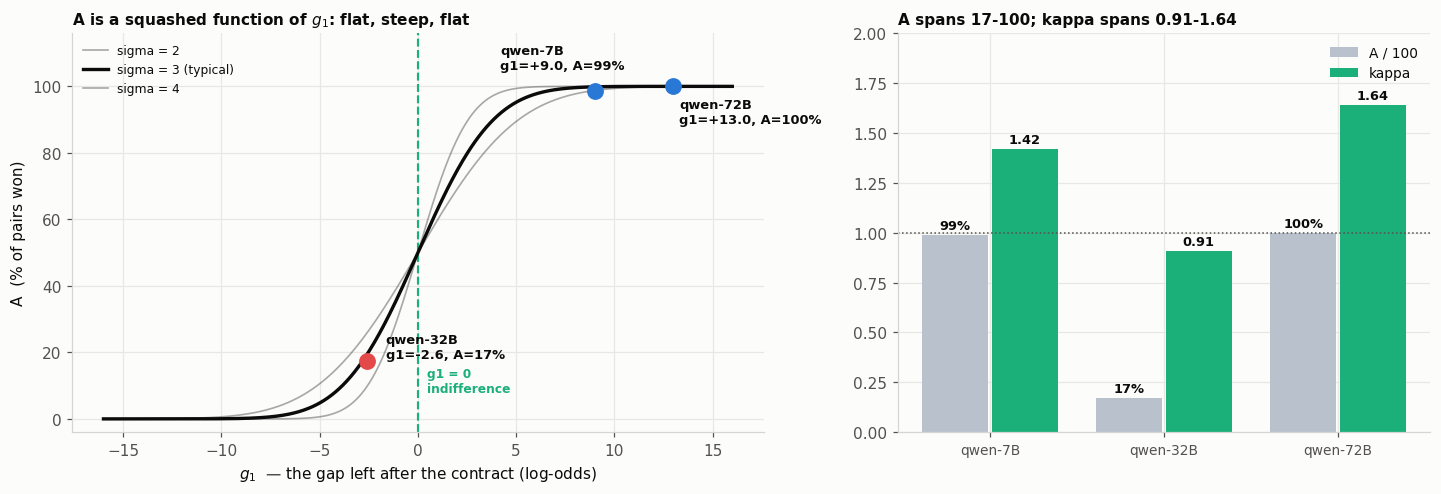

each model with its OWN g0 and sigma (sharing one g0 across models would be wrong):

             g0   push     g1    sd  kappa  A_pred  A_obs
qwen-7B  -21.38  30.39   9.01  2.48   1.42   99.99   98.7
qwen-32B -27.35  24.78  -2.57  3.14   0.91   20.65   17.3
qwen-72B -20.35  33.34  12.99  1.71   1.64  100.00  100.0

A_pred = 100*Phi(g1/sigma) tracks the observed A closely, which confirms A is just
g1 passed through a squashing function - it adds no information g1 does not have.

Why qwen-32B looks like an outlier and is not:
  it has the LARGEST |g0| (27.35) and the SMALLEST push (24.78), so g1 lands at -2.56,
  just barely negative. kappa = 0.91 - it surrendered 91% of its preference.
  A turns that 9% shortfall into '17% vs 99%' because -2.56 is in the steep region.


In [8]:
# the real measured numbers: (g0, push, sd of D across pairs, observed A)
# each model has its OWN g0 and sigma - they must not be shared.
REAL = {
    "qwen-7B":  dict(g0=-21.38, push=30.39, sd=2.48, A_obs=98.7),
    "qwen-32B": dict(g0=-27.35, push=24.78, sd=3.14, A_obs=17.3),
    "qwen-72B": dict(g0=-20.35, push=33.34, sd=1.71, A_obs=100.0),
}
for v in REAL.values():
    v["g1"] = v["g0"] + v["push"]
    v["kappa"] = 1 - v["g1"] / v["g0"]
    v["A_pred"] = 100 * norm.cdf(v["g1"] / v["sd"])
RE = pd.DataFrame(REAL).T

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6),
                         gridspec_kw={"width_ratios": [1.3, 1]})

# --- left: A as a function of g1. All three models live on this curve.
ax = axes[0]
xs = np.linspace(-16, 16, 500)
for sd, alpha in [(2.0, .35), (3.0, 1.0), (4.0, .35)]:
    ax.plot(xs, 100 * norm.cdf(xs / sd), color=INK, lw=2.2 if sd == 3 else 1.1,
            alpha=alpha, zorder=3,
            label=f"sigma = {sd:.0f}" + (" (typical)" if sd == 3 else ""))
ax.axvline(0, color="#1baf7a", lw=1.4, ls="--")
ax.annotate("g1 = 0\nindifference", (0, 8), textcoords="offset points", xytext=(6, 0),
            fontsize=8, color="#1baf7a", fontweight="bold")
OFFSET = {"qwen-7B": (-62, 14), "qwen-32B": (12, 2), "qwen-72B": (4, -24)}
for name, v in REAL.items():
    ax.plot([v["g1"]], [v["A_obs"]], "o", ms=10, zorder=6,
            color="#e34948" if name == "qwen-32B" else "#2a78d6")
    ax.annotate(f"{name}\ng1={v['g1']:+.1f}, A={v['A_obs']:.0f}%",
                (v["g1"], v["A_obs"]), textcoords="offset points",
                xytext=OFFSET[name], fontsize=8.5, fontweight="bold")
ax.set_xlabel("$g_1$  — the gap left after the contract (log-odds)")
ax.set_ylabel("A  (% of pairs won)")
ax.set_ylim(-4, 116)
ax.set_title("A is a squashed function of $g_1$: flat, steep, flat",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper left")

# --- right: the same three models on both metrics
ax = axes[1]
x = np.arange(3)
ax.bar(x - .2, RE.A_obs.astype(float) / 100, .38, color="#b9c2cc", zorder=2, label="A / 100")
ax.bar(x + .2, RE.kappa.astype(float), .38, color="#1baf7a", zorder=2, label="kappa")
ax.axhline(1, color=INK_MUTED, lw=1, ls=":")
for i, (name, v) in enumerate(REAL.items()):
    ax.text(i - .2, v["A_obs"] / 100 + .03, f"{v['A_obs']:.0f}%", ha="center",
            fontsize=8.5, fontweight="bold")
    ax.text(i + .2, v["kappa"] + .03, f"{v['kappa']:.2f}", ha="center",
            fontsize=8.5, fontweight="bold")
ax.set_xticks(x, list(REAL), fontsize=9)
ax.set_ylim(0, 2.0)
ax.set_title("A spans 17-100; kappa spans 0.91-1.64", loc="left",
             fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

print("each model with its OWN g0 and sigma (sharing one g0 across models would be wrong):\n")
print(RE[["g0", "push", "g1", "sd", "kappa", "A_pred", "A_obs"]].astype(float)
        .round(2).to_string())
print("\nA_pred = 100*Phi(g1/sigma) tracks the observed A closely, which confirms A is just")
print("g1 passed through a squashing function - it adds no information g1 does not have.")
print("\nWhy qwen-32B looks like an outlier and is not:")
print("  it has the LARGEST |g0| (27.35) and the SMALLEST push (24.78), so g1 lands at -2.56,")
print("  just barely negative. kappa = 0.91 - it surrendered 91% of its preference.")
print("  A turns that 9% shortfall into '17% vs 99%' because -2.56 is in the steep region.")

**The lesson.** $A$ answers a question people care about ("did it actually pick the right
laptop?") but it is a blunt instrument near the boundary and useless once saturated. $g$ and
$\kappa$ keep resolving. Report $\kappa$ next to $A$, always, and quote $g_0$ so the reader can
see whether $\kappa$ is trustworthy.

---
## Step 7 — $S$ and $\tilde{w}$: comparing two models with different volume

Two models can have the **same** preferences and still produce completely different log-odds,
because the scale of the weights is a free parameter of the fit — a nuisance, not a finding
(`progress.md` 2026-08-12). So raw weights cannot be compared across models.

The fix is to divide by how much the model cares **in total**:

$$S \;=\; \sum_f \Big[\max_{\ell} w_f(\ell) - \min_{\ell} w_f(\ell)\Big]
\;=\; u(\text{best laptop}) - u(\text{worst laptop}),
\qquad \tilde{w}_f(\ell) = \frac{w_f(\ell)}{S} .$$

The second equality holds exactly when every feature combination exists in the item set, which it
does (full factorial). So $S$ is not an abstraction: it is the utility gap between the best and
worst laptop on the table.

$\tilde{w}$ then reads as *"what share of everything this model cares about is this level?"* —
and **that** is comparable between a loud model and a quiet one. Below: a "quiet" twin with
preferences scaled by $0.1$. Raw weights differ 10x; normalised weights are identical.

In [9]:
QUIET = 0.1
w_quiet = {f: {l: v * QUIET for l, v in levels.items()} for f, levels in TRUE_W.items()}
# a DIFFERENT seed on purpose: sharing the seed would give both models identical noise, which
# cancels in the comparison and flatters the result. Independent noise is the honest test.
run_quiet = simulate(w=w_quiet, seed=7)

def spread_and_norm(w):
    S = sum(max(w[f"{f}_{l}"] for l in levels) - min(w[f"{f}_{l}"] for l in levels)
            for f, levels in TRUE_W.items())
    return S, {f"{f}_{l}": w[f"{f}_{l}"] / S for f, levels in TRUE_W.items() for l in levels}

w_loud = fit_bt(run0)
w_quie = fit_bt(run_quiet)
S_loud, n_loud = spread_and_norm(w_loud)
S_quie, n_quie = spread_and_norm(w_quie)

keys = [f"{f}_{l}" for f, levels in TRUE_W.items() for l in levels]
cmp = pd.DataFrame({
    "raw loud": [w_loud[k] for k in keys],
    "raw quiet": [w_quie[k] for k in keys],
    "norm loud": [n_loud[k] for k in keys],
    "norm quiet": [n_quie[k] for k in keys]}, index=keys)
print(cmp.round(4).to_string())
print(f"\nS (total spread):  loud {S_loud:.3f}   quiet {S_quie:.3f}   ratio {S_loud/S_quie:.1f}x")
print(f"correlation of RAW  weights: {np.corrcoef([w_loud[k] for k in keys], [w_quie[k] for k in keys])[0,1]:.4f}")
print(f"correlation of NORM weights: {np.corrcoef([n_loud[k] for k in keys], [n_quie[k] for k in keys])[0,1]:.4f}")

best = max(ITEMS, key=true_u); worst = min(ITEMS, key=true_u)
print(f"\nS really is the best-worst gap: u({best['brand']}/{best['ram']}) - "
      f"u({worst['brand']}/{worst['ram']}) = {true_u(best) - true_u(worst):.1f} (true), "
      f"{S_loud:.2f} (fitted)")

print("\n--- two things to take away ---\n")
print("1. Pearson r is INVARIANT to scale. Multiplying every weight by 0.1 cannot change r at")
print("   all, so a high r between two models says NOTHING about whether they are equally loud.")
print("   That is exactly why the base-vs-aligned figure reports r AND S side by side: r = 0.990")
print("   says 'same tastes', S says 'aligned is ~9x louder'. Neither implies the other.\n")
print("2. The quiet model's BRAND weights are badly recovered, because scaling by 0.1 pushed")
print("   brand (+-0.06) below the noise floor (sd 0.30) while ram (+-0.30) survived:")
for f in TRUE_W:
    ks = [f"{f}_{l}" for l in TRUE_W[f]]
    r_f = np.corrcoef([w_loud[k] for k in ks], [w_quie[k] for k in ks])[0, 1]
    print(f"     {f:6}: r = {r_f:+.3f}")
print("   This is the same effect as the real data, where base-vs-aligned agreement is 0.99 on")
print("   ram but only 0.79 on brand. Small features are noisy features. It is not a finding")
print("   about brand preference - it is a signal-to-noise fact.")

              raw loud  raw quiet  norm loud  norm quiet
brand_Apple     0.6057     0.0460     0.0857      0.0684
brand_ASUS      0.1917     0.0073     0.0271      0.0109
brand_Dell     -0.0137    -0.0210    -0.0019     -0.0313
brand_HP       -0.3023     0.0054    -0.0428      0.0081
brand_Lenovo   -0.4813    -0.0377    -0.0681     -0.0561
ram_4GB        -2.9913    -0.2940    -0.4231     -0.4371
ram_8GB        -0.0012    -0.0008    -0.0002     -0.0012
ram_16GB        2.9925     0.2948     0.4232      0.4383

S (total spread):  loud 7.071   quiet 0.672   ratio 10.5x
correlation of RAW  weights: 0.9943
correlation of NORM weights: 0.9943

S really is the best-worst gap: u(Apple/16GB) - u(Lenovo/4GB) = 7.1 (true), 7.07 (fitted)

--- two things to take away ---

1. Pearson r is INVARIANT to scale. Multiplying every weight by 0.1 cannot change r at
   all, so a high r between two models says NOTHING about whether they are equally loud.
   That is exactly why the base-vs-aligned figure repor

---
## Cheat sheet

| you want to know | use | not |
|---|---|---|
| did the model prefer x over y? | $D(x,y) > 0$ | $m > 0$ — displaced by $\gamma$ and $C$ |
| how strong is the preference? | $g$ (log-odds) | $A$, which saturates |
| how much did the contract change it? | $\kappa = 1 - g_1/g_0$ | difference of raw weights across models |
| how big is the positional bias? | $\beta_0 + C$ | $\beta_0$ alone |
| is this level important to the model? | $\tilde{w} = w/S$ | raw $w$ across models |
| how much does the model care at all? | $S$ | — |

**Three traps, in one place:**

1. **The shift.** A stored margin is displaced by $\gamma - C$. Any test of the form $m > 0$
   inherits that displacement. A "50%" produced this way means *no signal*, not *no preference*.
2. **$A$ saturates.** It is $\approx \Phi(g_1/\sigma)$, so near the boundary tiny differences in
   $g_1$ become huge differences in $A$ (qwen-32B), and far from it $A$ stops moving at all.
3. **Scale is not preference.** A louder model is not a model with different tastes. Compare
   $\tilde{w}$, or $\kappa$, never raw log-odds across models.

**Where the real versions live:** `figs4deck5_fix.ipynb` (contracts, one model family) and
`pretrained_vs_instruct.ipynb` (base vs aligned). Both use exactly the functions rebuilt here.